# **Heart Disease Prediction from Medical Data**

# CodeAlpha - Machine Learning Interneship - Task-3 
## Name: Muhammad Irfan Shafique - ID: DHC-2046

## Importing packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from matplotlib.ticker import MultipleLocator
from sklearn.model_selection import train_test_split,learning_curve,cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,f1_score,recall_score,roc_curve,roc_auc_score
from scipy.stats import chi2_contingency,pointbiserialr
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier

## Load the dataset into data frame

In [2]:
heart = pd.read_csv("heart-disease.csv")

## Dataset Overview & Statistical Summary

#### Dataset Features

**age:** Age of patient  

**sex:** Gender of patient
  * 0: Female
  * 1: Male
     
**cp:** Chest Pain Type  
  * 0: Typical angina
  * 1: Atypical angina
  * 2: Non-anginal pain
  * 3: Asymptomatic    

**trtbps:** Resting blood pressure (in mm Hg) 
* Normal: 90 – 120  mm Hg
* Elevated: 121 – 130  mm Hg
* Hypertension: > 130 mm Hg

**chol:** Serum cholesterol (in mg/dL)    

**fbs:** Fasting blood sugar 
* 0: Fasting blood sugar ≤ 120 mg/dL  
* 1: Fasting blood sugar > 120 mg/dL
    
**restecg:** Resting electrocardiographic results 
* 0: Normal
* 1: ST-T wave abnormality
* 2: Left ventricular hypertrophy
    
**thalachh:** Maximum heart rate achieved    

**exng:** Exercise-induced angina. Reflects whether the patient experiences angina (chest pain) during exercise, which is a potential marker of heart disease.
* 0: No
* 1: Yes

**oldpeak:** ST segment depression induced by exercise relative to rest (in mm). Measures changes in the ST segment of an ECG during physical activity. A **higher value** often signals **ischemia (reduced blood flow to the heart)** 
* 0: No ST depression
* Greater than 0 to 1: Mild
* Greater than 1 to 2: Moderate
* Greater than 2: Severe

**slp:** Slope of the peak exercise ST segment 
* 0: Upsloping indicates lower risk
* 1: Flat indicates suspicious or intermediate concern
* 2: Downsloping indicates highest concern for heart disease
    
**caa:** Number of major vessels **(0 – 4)** colored by fluoroscopy. Indicates the number of major blood vessels with significant narrowing. 
* Lower value: indicates greater risk 
* Higher value: suggests better heart health
 
**thall:** Thalassemia type 
* 0: Null
* 1: Fixed defect
* 2: Normal
* 3: Reversible defect
  
**output:** Heart disease presence status 
* 0: No heart disease
* 1: Heart disease present  

In [3]:
heart.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**Number of Rows and Columns in the Dataset**

In [4]:
rows, cols = heart.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 303
Number of columns: 14


In [5]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
heart.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302    False
Length: 303, dtype: bool

**No Duplicate Rows**

In [7]:
continuous_cols = ["age", "trtbps", "chol", "thalachh", "oldpeak"] 
continuous_summary = heart[continuous_cols].describe().round(2)

binary_cols=["sex", "fbs", "exng", "output"]
binary_summary = pd.DataFrame({
    'total count': heart[binary_cols].count(),
    'count of 0': (heart[binary_cols] == 0).sum(),
    'percentage of 0': ((heart[binary_cols] == 0).mean() * 100).round(2),
    'count of 1': (heart[binary_cols] == 1).sum(),
    'percentage of 1': ((heart[binary_cols] == 1).mean() * 100).round(2)
})

categorical_cols = ["cp", "restecg", "slp","caa", "thall"]
categorical_summary = pd.DataFrame({
    'total count': heart[categorical_cols].count(),
    'count of 0': (heart[categorical_cols] == 0).sum(),
    'percentage of 0': ((heart[categorical_cols] == 0).mean() * 100).round(2),
    'count of 1': (heart[categorical_cols] == 1).sum(),
    'percentage of 1': ((heart[categorical_cols] == 1).mean() * 100).round(2),
    'count of 2': (heart[categorical_cols] == 2).sum(),
    'percentage of 2': ((heart[categorical_cols] == 2).mean() * 100).round(2),
    'count of 3': (heart[categorical_cols] == 3).sum(),
    'percentage of 3': ((heart[categorical_cols] == 3).mean() * 100).round(2),
    'count of 4': (heart[categorical_cols] == 4).sum(),
    'percentage of 4': ((heart[categorical_cols] == 4).mean() * 100).round(2)
})

display(HTML("<h4><b>Continuous Variables Summary</b></h4>"))
display(continuous_summary)

display(HTML("<h4><b>Dichotomous (Two-Categories/Binary) Variables Summary</b></h4>"))
display(HTML("<h4><b>Categories: 0, 1</b></h4>"))
display(binary_summary)

display(HTML("<h4><b>Polytomous (Three or More Categories) Variables Summary</b></h4>"))
display(HTML("<h4><b>Categories: 0, 1, 2, 3, 4</b></h4>"))
display(categorical_summary)

,age,trtbps,chol,thalachh,oldpeak
count,303.00,303.00,303.00,303.00,303.00
mean,54.37,131.62,246.26,149.65,1.04
std,9.08,17.54,51.83,22.91,1.16
min,29.00,94.00,126.00,71.00,0.00
25%,47.50,120.00,211.00,133.50,0.00
50%,55.00,130.00,240.00,153.00,0.80
75%,61.00,140.00,274.50,166.00,1.60
max,77.00,200.00,564.00,202.00,6.20


,total count,count of 0,percentage of 0,count of 1,percentage of 1
sex,303,96,31.68,207,68.32
fbs,303,258,85.15,45,14.85
exng,303,204,67.33,99,32.67
output,303,138,45.54,165,54.46


,total count,count of 0,percentage of 0,count of 1,percentage of 1,count of 2,percentage of 2,count of 3,percentage of 3,count of 4,percentage of 4
cp,303,143,47.19,50,16.50,87,28.71,23,7.59,0,0.00
restecg,303,147,48.51,152,50.17,4,1.32,0,0.00,0,0.00
slp,303,21,6.93,140,46.20,142,46.86,0,0.00,0,0.00
caa,303,175,57.76,65,21.45,38,12.54,20,6.60,5,1.65
thall,303,2,0.66,18,5.94,166,54.79,117,38.61,0,0.00


# EDA (Exploratory Data Analysis)

In [8]:
heart.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

##### No NULL value found

In [9]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## **Gender-wise Summary of Heart Disease Cases and Prevalence**

In [10]:
summary_table = heart.groupby('sex')['output'].agg(
    Total_Patients='count',
    Heart_Disease_Cases='sum'
)

summary_table.index = summary_table.index.map({0: 'Female', 1: 'Male'})

summary_table['Heart_Disease_Percentage_Within_Gender'] = (
    summary_table['Heart_Disease_Cases'] / summary_table['Total_Patients'] * 100
).round(2)

# Add total row
summary_table.loc['Total'] = [
    summary_table['Total_Patients'].sum(),
    summary_table['Heart_Disease_Cases'].sum(),
    summary_table['Heart_Disease_Cases'].sum() / summary_table['Total_Patients'].sum()*100 
]

display(HTML("<h4><b>Heart Disease Occurrence Across Male and Female Patients</b></h4>"))

display(
    summary_table.style.format({
        'Total_Patients': '{:.0f}',
        'Heart_Disease_Cases': '{:.0f}',
        'Heart_Disease_Percentage_Within_Gender': '{:.2f}%'
    })
)


,Total_Patients,Heart_Disease_Cases,Heart_Disease_Percentage_Within_Gender
sex,,,
Female,96,72,75.00%
Male,207,93,44.93%
Total,303,165,54.46%


## **Heart Disease Distribution by Sex**

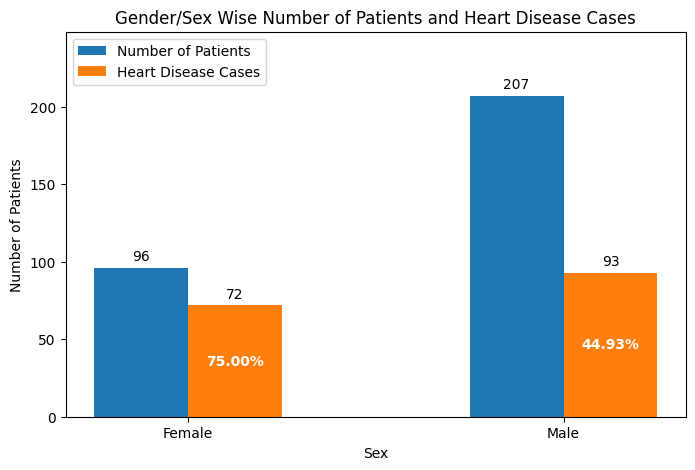

In [11]:
# Exclude Total row for chart
chart_data = summary_table.drop('Total')

x = np.arange(len(chart_data.index))
width = 0.25

plt.figure(figsize=(8, 5))

bars1 = plt.bar(x - width/2, chart_data['Total_Patients'], width, label='Number of Patients')
bars2 = plt.bar(x + width/2, chart_data['Heart_Disease_Cases'], width, label='Heart Disease Cases')

plt.xticks(x, chart_data.index)
plt.title('Gender/Sex Wise Number of Patients and Heart Disease Cases')
plt.xlabel('Sex')
plt.ylabel('Number of Patients')
plt.legend()

# Add extra space above bars
max_height = max(chart_data['Total_Patients'].max(), chart_data['Heart_Disease_Cases'].max())
plt.ylim(0, max_height * 1.20)   # 20% extra top space

# Count over each bar
plt.bar_label(bars1, fmt='%.0f', padding=3)
plt.bar_label(bars2, fmt='%.0f', padding=3)

# Percentage inside Heart_Disease_Cases bars
for bar, pct in zip(bars2, chart_data['Heart_Disease_Percentage_Within_Gender']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height / 2,
        f'{pct:.2f}%',
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

## **Comparative Proportion of Heart Disease Among Male and Female Patients**

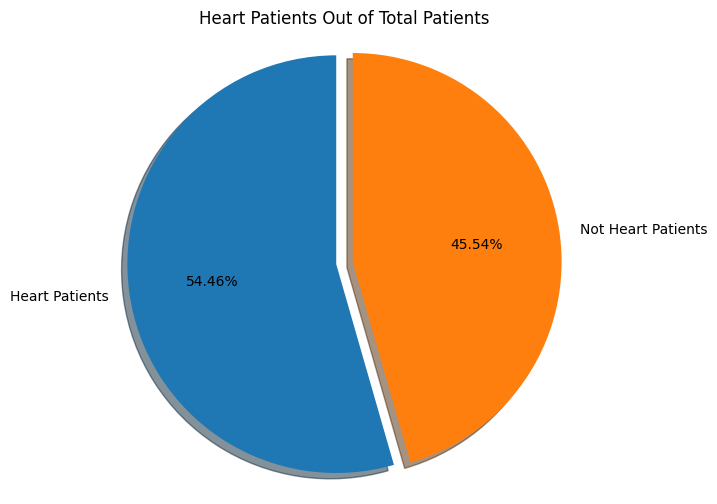

In [12]:
# Pie Chart:
# Heart patients out of total patients

total_patients = summary_table.loc['Total', 'Total_Patients']
total_heart_patients = summary_table.loc['Total', 'Heart_Disease_Cases']
non_heart_patients = total_patients - total_heart_patients

labels = ['Heart Patients', 'Not Heart Patients']
sizes = [total_heart_patients, non_heart_patients]
explode = (0.08, 0)

plt.figure(figsize=(6, 6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    explode=explode,
    shadow=True
)

plt.title('Heart Patients Out of Total Patients')
plt.axis('equal')
plt.show()

## **Gender-wise Difference in Heart Disease Percentage**

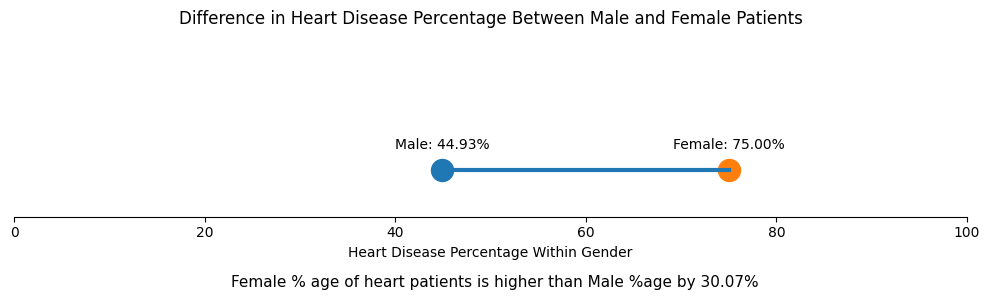

In [13]:
# Data for dumbbell chart

female_pct = summary_table.loc['Female', 'Heart_Disease_Percentage_Within_Gender']
male_pct = summary_table.loc['Male', 'Heart_Disease_Percentage_Within_Gender']

difference = abs(female_pct - male_pct)

# Identify higher category
if female_pct > male_pct:
    higher_label = 'Female'
    lower_label = 'Male'
else:
    higher_label = 'Male'
    lower_label = 'Female'


# Dumbbell Chart

plt.figure(figsize=(10, 4))

y = 0

# Connecting line
plt.plot([male_pct, female_pct], [y, y], linewidth=3)

# Points
plt.scatter(male_pct, y, s=250)
plt.scatter(female_pct, y, s=250)

# Labels above points
plt.annotate(
    f'Male: {male_pct:.2f}%',
    xy=(male_pct, y),
    xytext=(0, 15),
    textcoords='offset points',
    ha='center',
    fontsize=10
)

plt.annotate(
    f'Female: {female_pct:.2f}%',
    xy=(female_pct, y),
    xytext=(0, 15),
    textcoords='offset points',
    ha='center',
    fontsize=10
)

# Formatting
plt.xlim(0, 100)
plt.ylim(-0.05, 0.15)
plt.yticks([])

# Reduce title gap
plt.title(
    'Difference in Heart Disease Percentage Between Male and Female Patients',
    pad=2
)

plt.xlabel('Heart Disease Percentage Within Gender')

# Put annotation BELOW x-axis label
plt.figtext(
    0.5, 0.02,
    f'{higher_label} % age of heart patients is higher than {lower_label} %age by {difference:.2f}%',
    ha='center',
    fontsize=11
)

# Clean style
for spine in ['left', 'right', 'top']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout(rect=[0, 0.05, 1, 0.75])
plt.show()

## **Frequency Distribution of Continuous Variables (Histograms)**

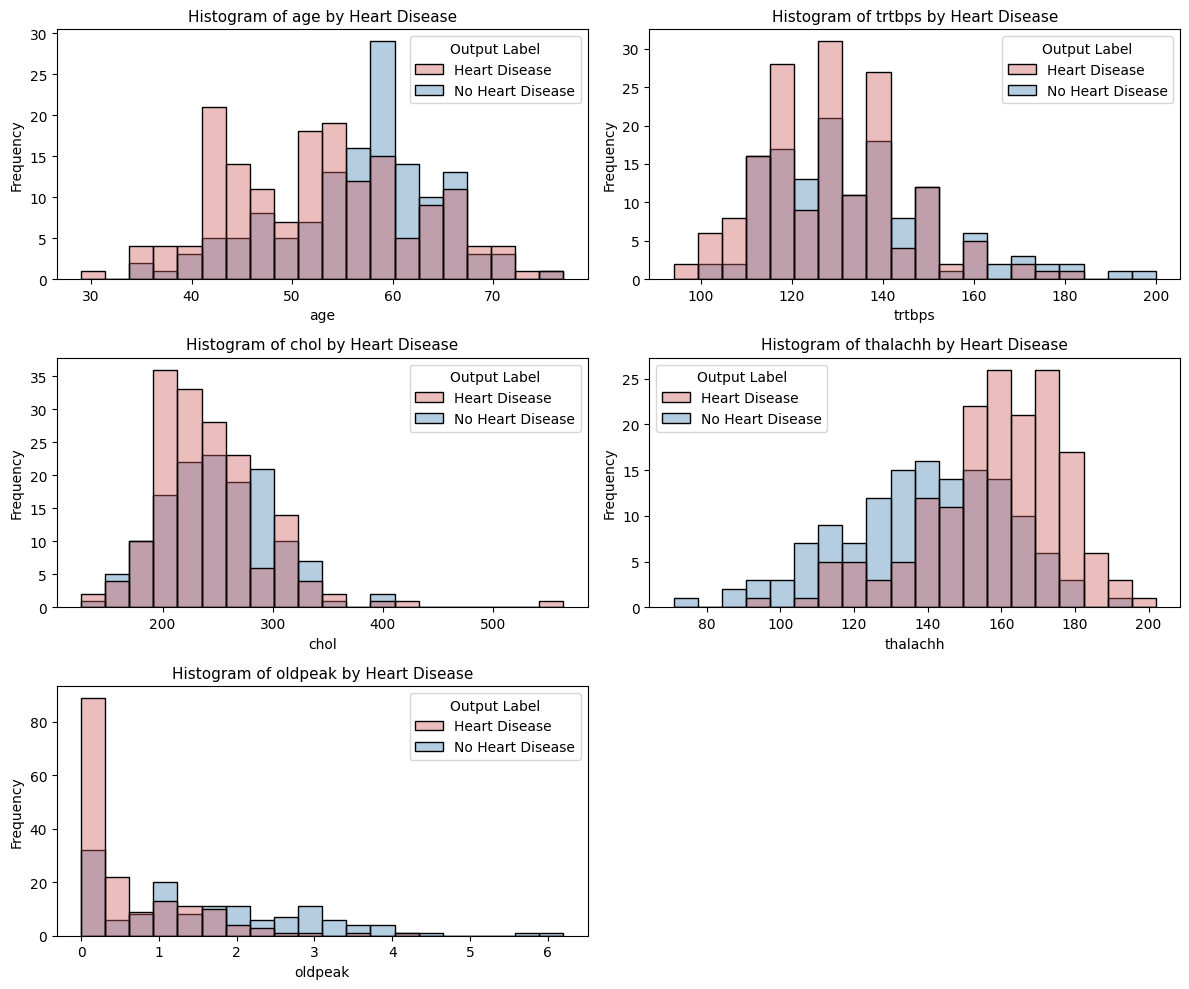

In [14]:
heart['Output Label'] = heart['output'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

cont_cols = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()

palette = {
    'No Heart Disease': 'steelblue',
    'Heart Disease': 'indianred'
}

for i, col in enumerate(cont_cols):
    sns.histplot(
        data=heart,
        x=col,
        hue='Output Label',
        bins=20,
        stat='count',
        common_norm=False,
        element='bars',
        alpha=0.4,
        palette=palette,
        ax=axes[i]
    )

    axes[i].set_title(f'Histogram of {col} by Heart Disease', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

if len(cont_cols) < len(axes):
    for j in range(len(cont_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **Density Distribution of Continuous Variables (KDE Curves)**

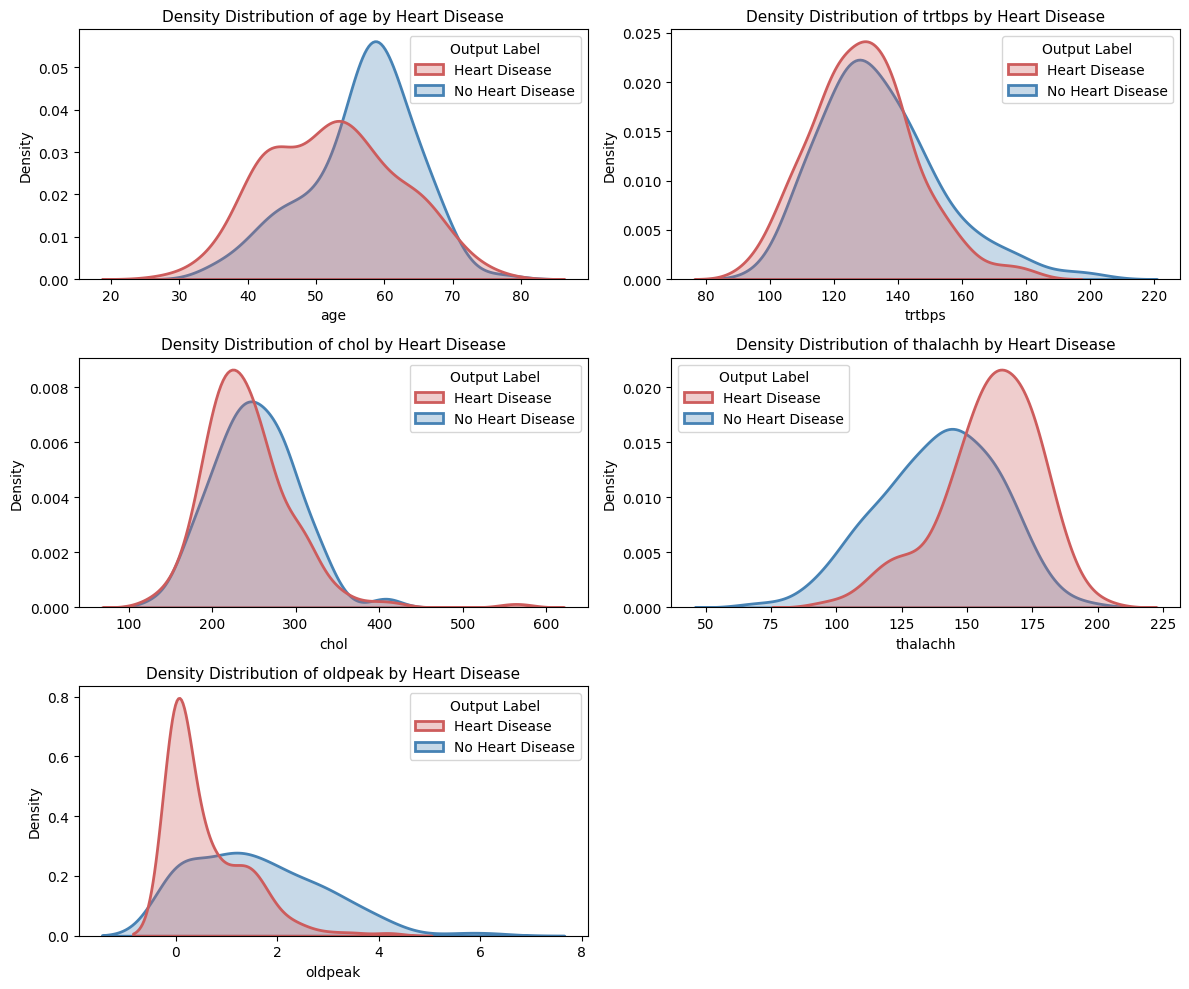

In [15]:
heart['Output Label'] = heart['output'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

cont_cols = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()

palette = {
    'No Heart Disease': 'steelblue',
    'Heart Disease': 'indianred'
}

for i, col in enumerate(cont_cols):
    sns.kdeplot(
        data=heart,
        x=col,
        hue='Output Label',
        common_norm=False,
        fill=True,              
        alpha=0.3,              
        linewidth=2,
        palette=palette,
        ax=axes[i]
    )

    axes[i].set_title(f'Density Distribution of {col} by Heart Disease', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

if len(cont_cols) < len(axes):
    for j in range(len(cont_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **Spread and Outlier Analysis of Continuous Variables**

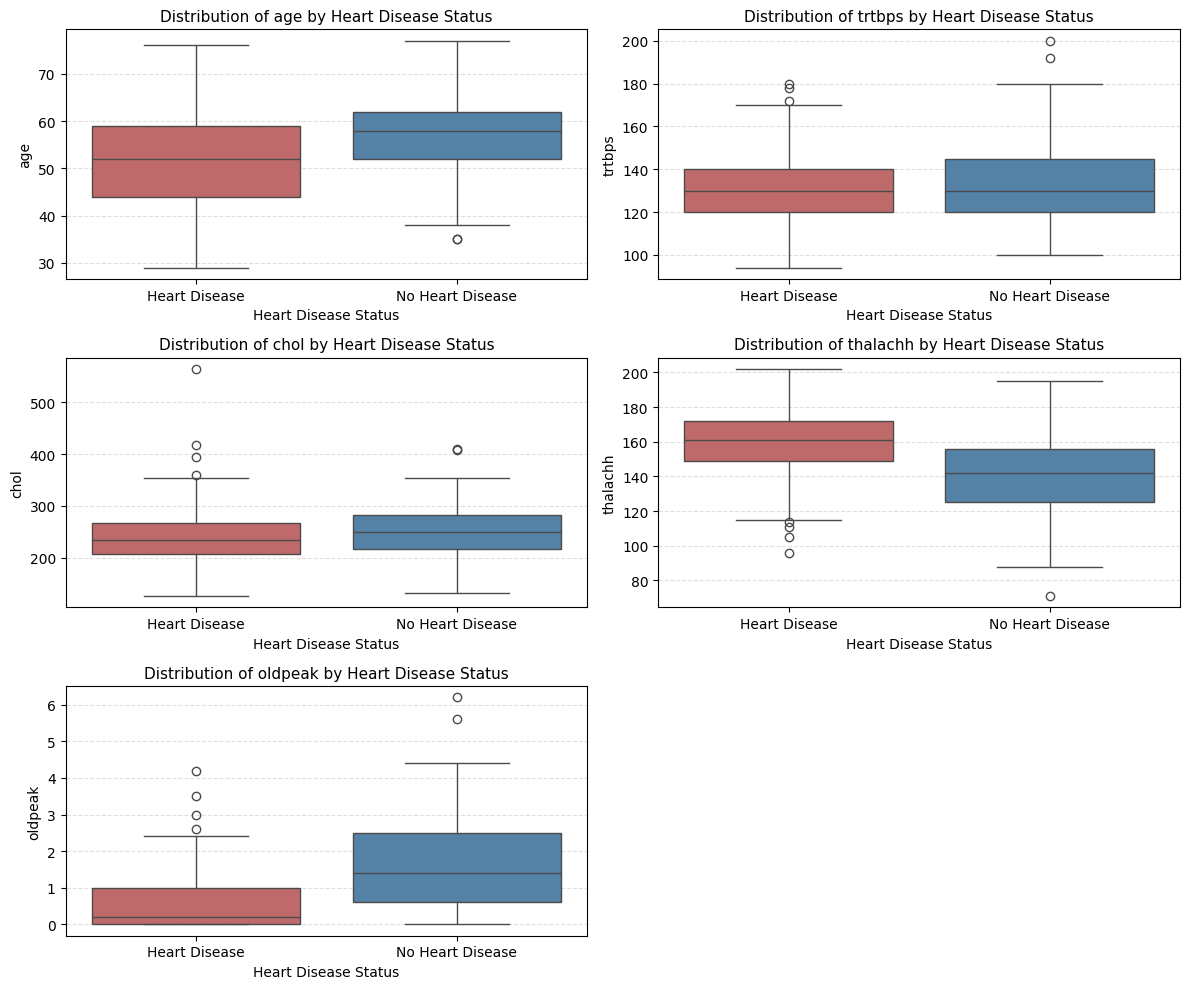

In [16]:
# Create readable labels
heart['Output Label'] = heart['output'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

palette = {
    'No Heart Disease': 'steelblue',
    'Heart Disease': 'indianred'
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    sns.boxplot(
        data=heart,
        x='Output Label',
        y=col,
        hue='Output Label',
        palette=palette,
        ax=axes[i]
    )
    
    # Remove duplicate legends from each subplot
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()
    
    axes[i].set_title(f'Distribution of {col} by Heart Disease Status', fontsize=11)
    axes[i].set_xlabel('Heart Disease Status')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

# Remove empty subplot if needed
if len(cont_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## **Density Distribution of Continuous Features Across Heart Disease Groups**

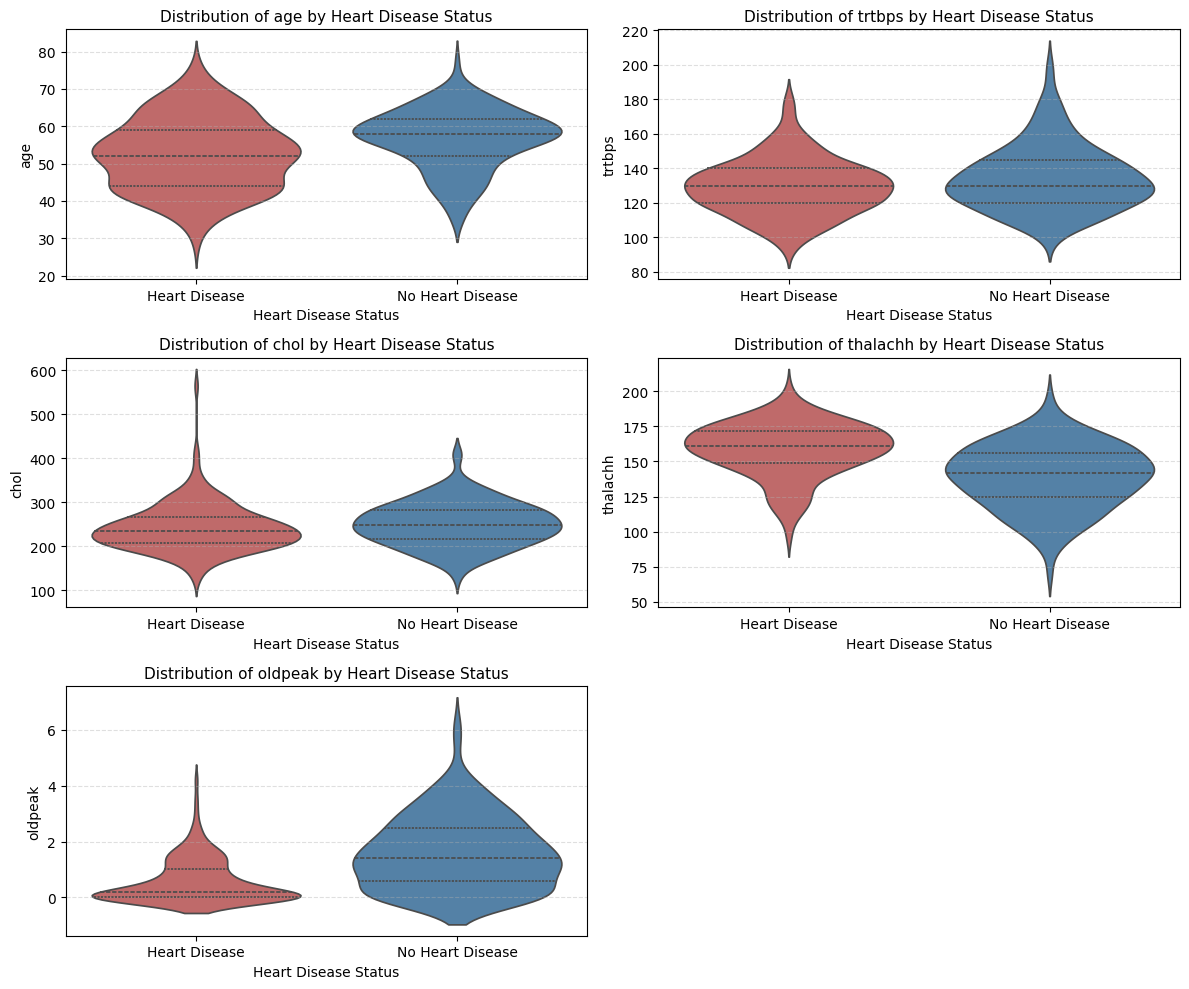

In [17]:
# Numerical columns
cont_cols = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

# Create readable labels
heart['Output Label'] = heart['output'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

palette = {
    'No Heart Disease': 'steelblue',
    'Heart Disease': 'indianred'
}

# Create subplot layout
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    sns.violinplot(
        data=heart,
        x='Output Label',
        y=col,
        hue='Output Label',
        inner='quartile',
        palette=palette,
        ax=axes[i]
    )
    
    # Remove duplicate legends from each subplot
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()
    
    axes[i].set_title(f'Distribution of {col} by Heart Disease Status', fontsize=11)
    axes[i].set_xlabel('Heart Disease Status')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

# Remove empty subplot if needed
if len(cont_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## **Heart Disease Status by Age Group and Gender**

In [18]:
# Create age groups
bins = [28, 38, 48, 58, 68, 78]
labels = ['29-38', '39-48', '49-58', '59-68', '69-78']

heart['Age Group'] = pd.cut(
    heart['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Create crosstab table
table = pd.crosstab(
    heart['Age Group'],
    [heart['sex'], heart['output']]
)

# Ensure all expected columns exist and are in correct order
table = table.reindex(
    columns=pd.MultiIndex.from_tuples([(0, 0), (0, 1), (1, 0), (1, 1)]),
    fill_value=0
)

table.columns = [
    'Females (Having No HD)',
    'Females (Having HD)',
    'Males (Having No HD)',
    'Males (Having HD)'
]

display(HTML("<h4><b>Count of Heart Disease Cases by Age Group and Sex</b></h4>"))

display(table)

,Females (Having No HD),Females (Having HD),Males (Having No HD),Males (Having HD)
Age Group,,,,
29-38,0,3,3,6
39-48,1,18,20,32
49-58,9,26,44,37
59-68,14,19,42,16
69-78,0,6,5,2


## **Distribution of Heart Disease Status by Age Group and Sex**

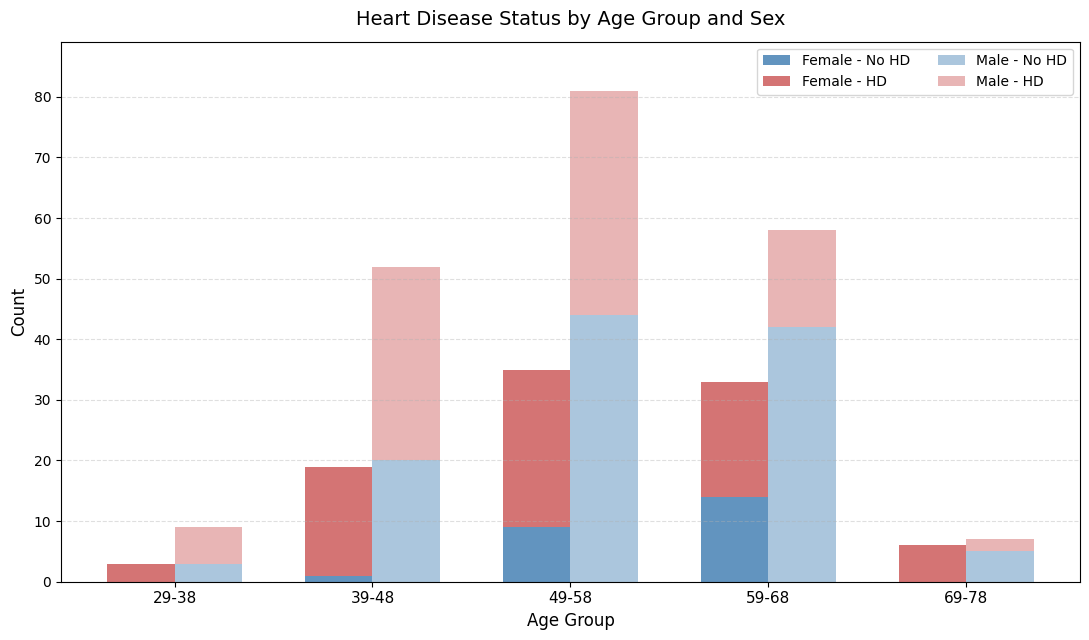

In [19]:
# Prepare data
female_no_hd = table['Females (Having No HD)']
female_hd    = table['Females (Having HD)']
male_no_hd   = table['Males (Having No HD)']
male_hd      = table['Males (Having HD)']

x = np.arange(len(table.index))
width = 0.34

plt.figure(figsize=(11, 6.5))

# Grouped stacked bars
plt.bar(
    x - width/2,
    female_no_hd,
    width,
    label='Female - No HD',
    color='steelblue',
    alpha=0.85
)

plt.bar(
    x - width/2,
    female_hd,
    width,
    bottom=female_no_hd,
    label='Female - HD',
    color='indianred',
    alpha=0.85
)

plt.bar(
    x + width/2,
    male_no_hd,
    width,
    label='Male - No HD',
    color='steelblue',
    alpha=0.45
)

plt.bar(
    x + width/2,
    male_hd,
    width,
    bottom=male_no_hd,
    label='Male - HD',
    color='indianred',
    alpha=0.45
)

# Axes and styling
plt.xticks(x, table.index, fontsize=11)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Heart Disease Status by Age Group and Sex', fontsize=14, pad=12)

plt.legend(ncol=2, fontsize=10, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Set y-limit with a little headroom
female_totals = female_no_hd + female_hd
male_totals = male_no_hd + male_hd
max_total = max(female_totals.max(), male_totals.max())
plt.ylim(0, max_total * 1.10)

plt.tight_layout()
plt.show()

## **Comparative Age Distribution Across Sex and Heart Disease Groups**

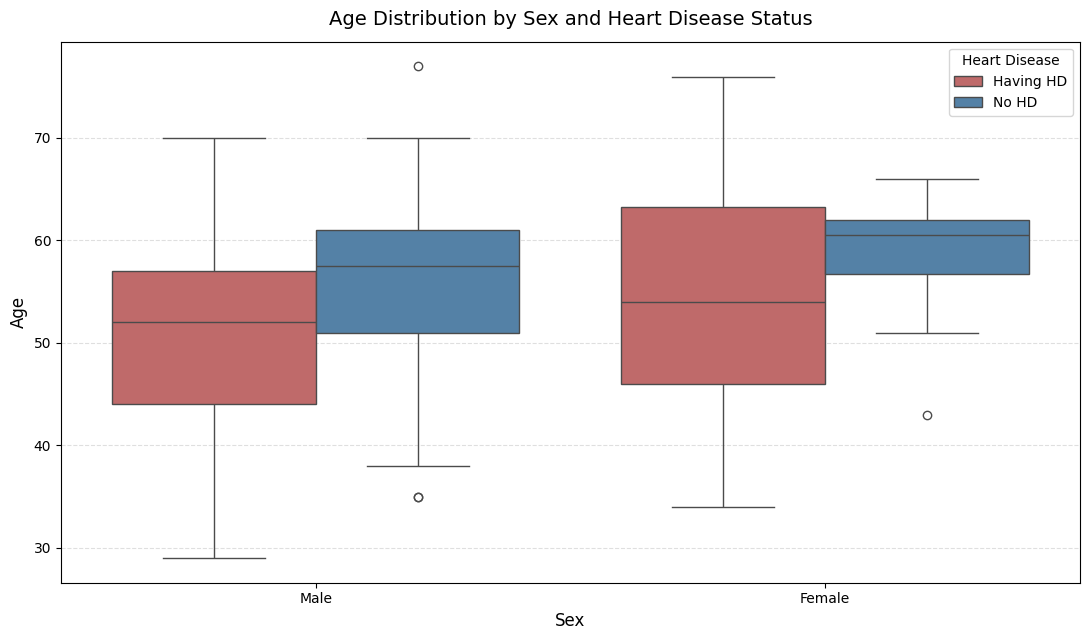

In [20]:
# BOX PLOT 

# Create readable labels
heart['Sex Label'] = heart['sex'].map({0: 'Female', 1: 'Male'})
heart['Heart Disease Label'] = heart['output'].map({0: 'No HD', 1: 'Having HD'})

palette = {
    'No HD': 'steelblue',
    'Having HD': 'indianred'
}

plt.figure(figsize=(11, 6.5))

sns.boxplot(
    data=heart,
    x='Sex Label',
    y='age',
    hue='Heart Disease Label',
    palette=palette
)

plt.xlabel('Sex', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.title('Age Distribution by Sex and Heart Disease Status', fontsize=14, pad=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Heart Disease', fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

## **Relationship Between Binary Variables and Heart Disease Status**

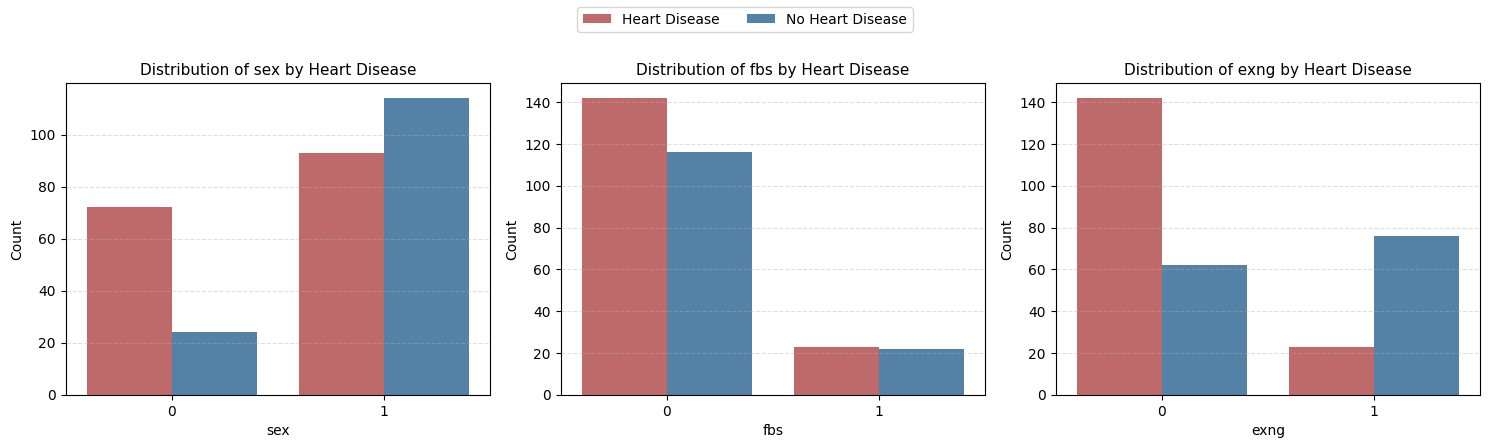

In [21]:
# Create readable labels
heart['Output Label'] = heart['output'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

# Only predictor binary columns
binary_cols = ['sex', 'fbs', 'exng']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5))
axes = axes.flatten()

palette = {
    'No Heart Disease': 'steelblue',
    'Heart Disease': 'indianred'
}

for i, col in enumerate(binary_cols):
    sns.countplot(
        data=heart,
        x=col,
        hue='Output Label',
        palette=palette,
        ax=axes[i]
    )
    
    axes[i].set_title(f'Distribution of {col} by Heart Disease', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

# Add one common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

## **Percentage Distribution of Heart Disease Status Across Categorical Variables**

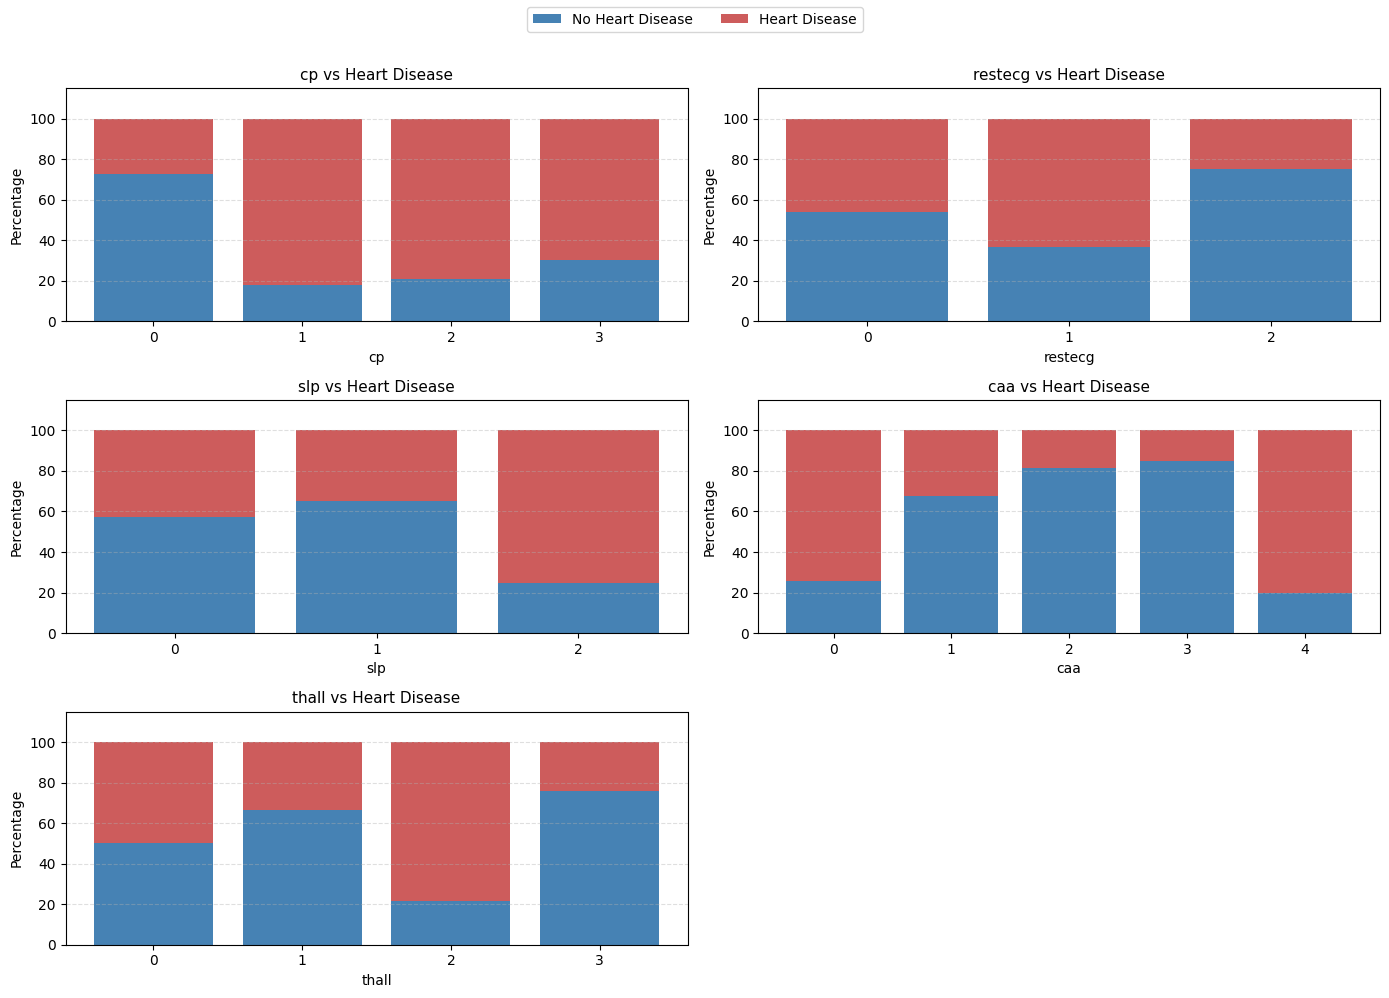

In [22]:
# Label mapping
heart['Output Label'] = heart['output'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

palette = {
    'No Heart Disease': 'steelblue',
    'Heart Disease': 'indianred'
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    
    # Create percentage table
    ct = pd.crosstab(heart[col], heart['Output Label'], normalize='index') * 100
    
    x = np.arange(len(ct.index))
    
    axes[i].bar(
        x,
        ct['No Heart Disease'],
        label='No Heart Disease',
        color='steelblue'
    )
    
    axes[i].bar(
        x,
        ct['Heart Disease'],
        bottom=ct['No Heart Disease'],
        label='Heart Disease',
        color='indianred'
    )
    
    axes[i].set_title(f'{col} vs Heart Disease', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(ct.index)
    axes[i].set_ylim(0, 115)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    # Remove duplicate legends
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

# Common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

# Remove empty subplot if needed
if len(categorical_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## **Continuous Variables vs Heart Disease Heatmap**
**Continuous Variable to Continuous Variable (Pearson correlation)**  
**Continuous Variable to Categorical Variable / Binary Variable i.e. output (Point-Biserial correlation)**

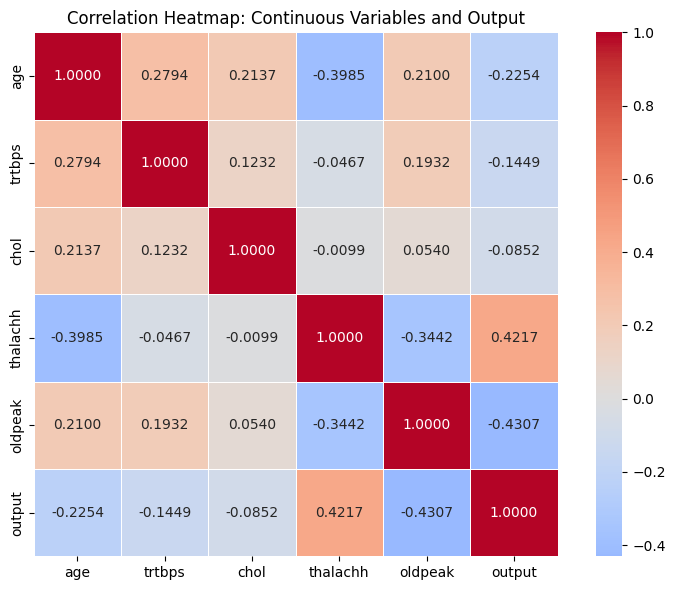

In [23]:
target_col = 'output'
corr_cols = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

# Start with Pearson correlation among continuous variables
full_corr = heart[corr_cols].corr()

# Add output row and column using Point-Biserial correlation
full_corr[target_col] = np.nan
full_corr.loc[target_col] = np.nan

for col in corr_cols:
    corr, _ = pointbiserialr(heart[target_col], heart[col])
    full_corr.loc[col, target_col] = corr
    full_corr.loc[target_col, col] = corr

# Set output-output correlation
full_corr.loc[target_col, target_col] = 1.0

# Reorder columns and rows
final_cols = corr_cols + [target_col]
full_corr = full_corr.loc[final_cols, final_cols]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    full_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.4f',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Correlation Heatmap: Continuous Variables and Output')
plt.tight_layout()
plt.show()

## **Pairwise Feature Relationships of Continuous Variables by Heart Disease Status**

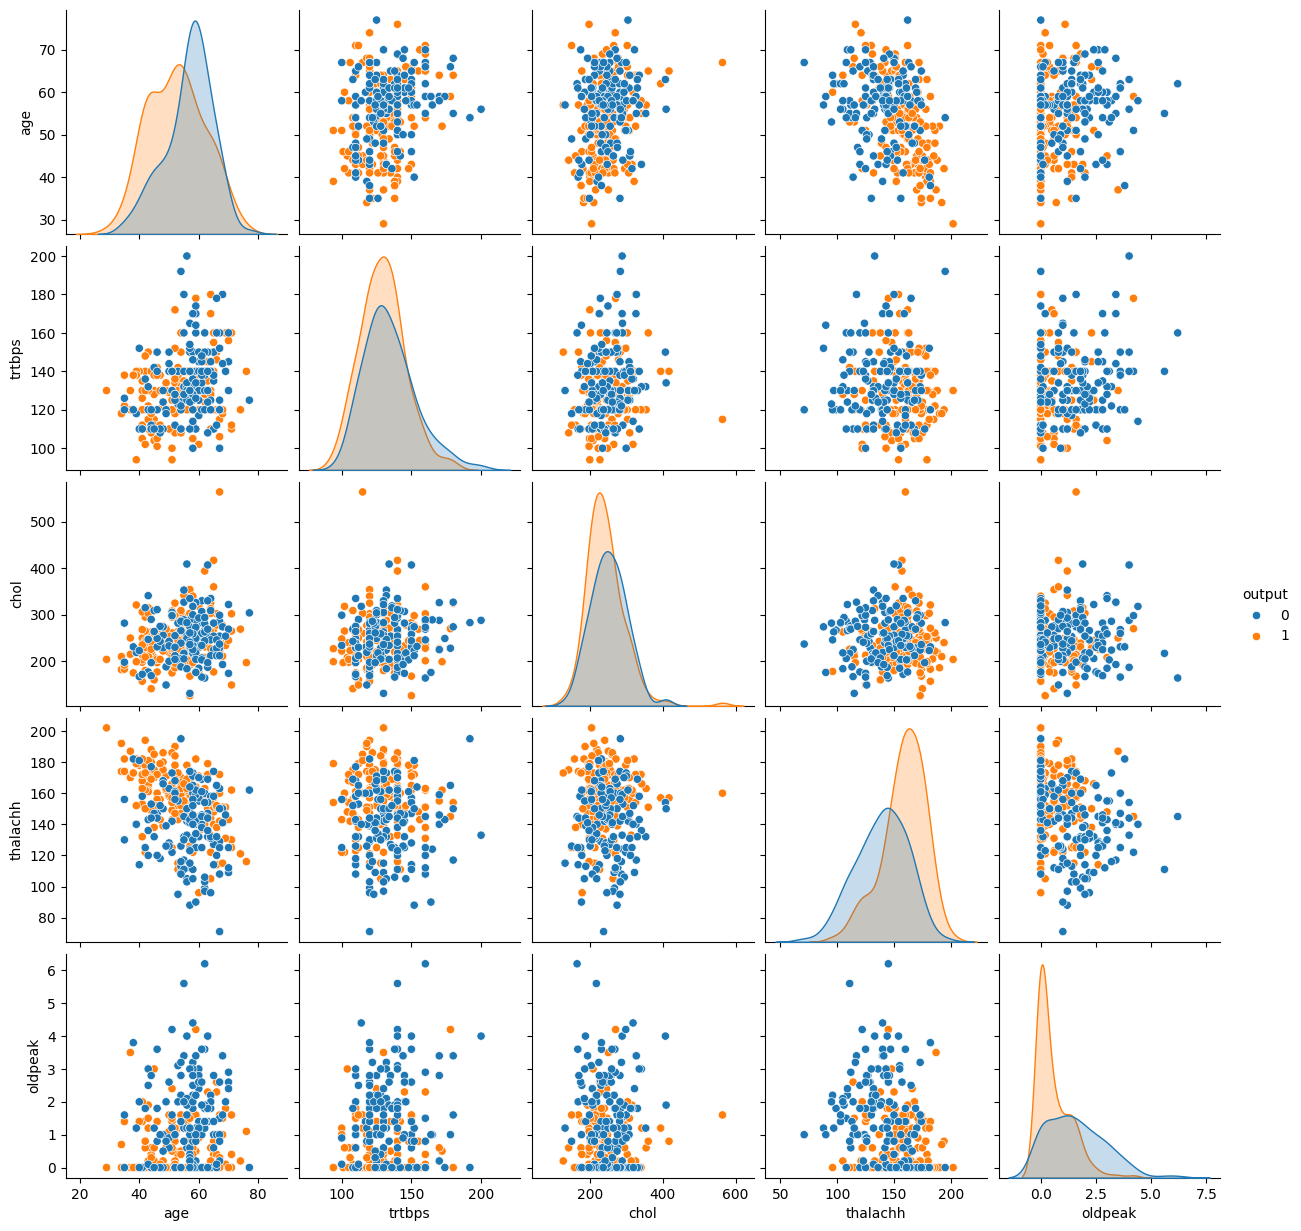

In [24]:
sns.pairplot(
    heart[['age','trtbps','chol','thalachh','oldpeak','output']],
    hue='output'
)

## **Association Analysis of Binary Features with Heart Disease (Chi-Square Test)**

In [25]:
bin_cols=["sex", "fbs", "exng"]

for col in bin_cols:
    contingency = pd.crosstab(heart[col], heart['output'])
    chi2, p, _, _ = chi2_contingency(contingency)
    
    print(f"{col} -> p-value: {p:.5f}")

sex -> p-value: 0.00000
fbs -> p-value: 0.74443
exng -> p-value: 0.00000


**Interpretation:**  
**p < 0.05 → statistically significant relationship**  
**p ≥ 0.05 → weak / no evidence**

## **Strength of Association Between Binary Variables and Heart Disease (Cramér’s V)**

In [26]:
bin_cols=["sex", "fbs", "exng"]

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

for col in bin_cols:
    cm = pd.crosstab(heart[col], heart['output'])
    print(f"{col} -> Cramér's V: {cramers_v(cm):.3f}")

sex -> Cramér's V: 0.274
fbs -> Cramér's V: 0.019
exng -> Cramér's V: 0.430


**Interpretation:**  
**0.1 → weak**  
**0.3 → moderate**  
**0.5 → strong**

## **Percentage Distribution of Heart Disease by Category**

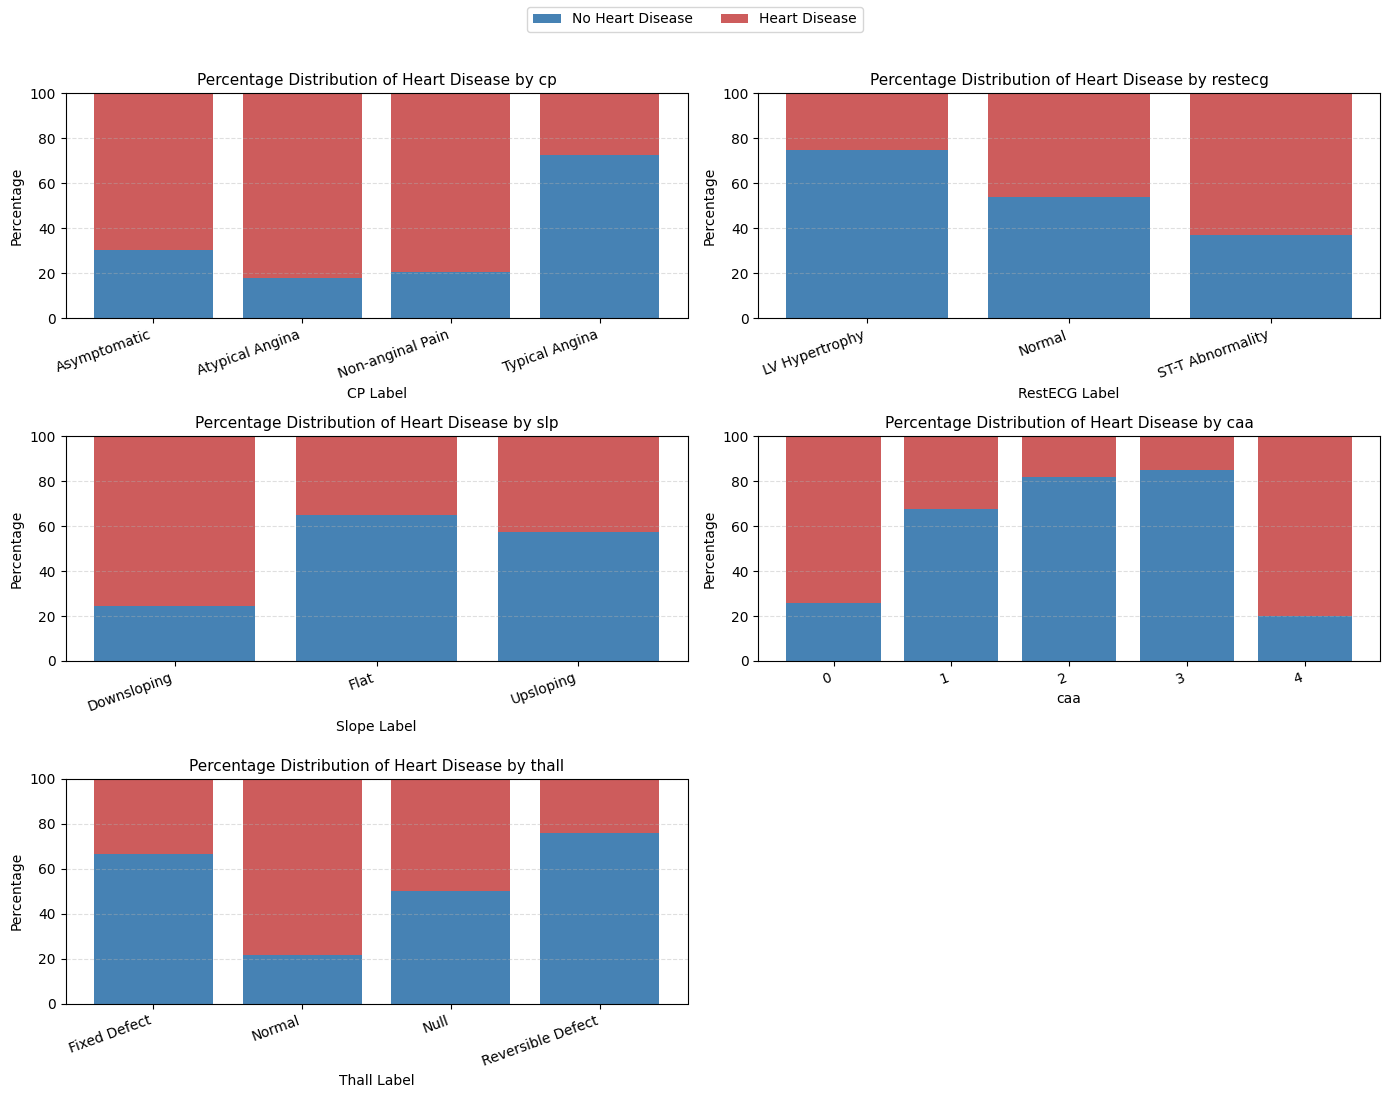

In [27]:
# Create readable label columns
heart['CP Label'] = heart['cp'].map({
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-anginal Pain',
    3: 'Asymptomatic'
})

heart['RestECG Label'] = heart['restecg'].map({
    0: 'Normal',
    1: 'ST-T Abnormality',
    2: 'LV Hypertrophy'
})

heart['Slope Label'] = heart['slp'].map({
    0: 'Upsloping',
    1: 'Flat',
    2: 'Downsloping'
})

heart['Thall Label'] = heart['thall'].map({
    0: 'Null',
    1: 'Fixed Defect',
    2: 'Normal',
    3: 'Reversible Defect'
})

heart['Output Label'] = heart['output'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

plot_label_map = {
    'cp': 'CP Label',
    'restecg': 'RestECG Label',
    'slp': 'Slope Label',
    'caa': 'caa',
    'thall': 'Thall Label'
}

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    plot_col = plot_label_map[col]

    pct = pd.crosstab(
        heart[plot_col],
        heart['Output Label'],
        normalize='index'
    ) * 100

    x = np.arange(len(pct.index))

    no_hd = pct.get('No Heart Disease', pd.Series(0, index=pct.index))
    hd = pct.get('Heart Disease', pd.Series(0, index=pct.index))

    axes[i].bar(
        x,
        no_hd,
        color='steelblue',
        label='No Heart Disease'
    )

    axes[i].bar(
        x,
        hd,
        bottom=no_hd,
        color='indianred',
        label='Heart Disease'
    )

    axes[i].set_title(f'Percentage Distribution of Heart Disease by {col}', fontsize=11)
    axes[i].set_xlabel(plot_col)
    axes[i].set_ylabel('Percentage')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(pct.index, rotation=20, ha='right')
    axes[i].set_ylim(0, 100)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## **Categorical Association Strength: Cramer’s V**

In [28]:
binary_cols = ["sex", "fbs", "exng"]
categorical_cols = ["cp", "restecg", "slp", "caa", "thall"]
target_col = "output"

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    if min(r - 1, k - 1) == 0:
        return np.nan

    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

assoc_results = []

for col in binary_cols + categorical_cols:
    val = cramers_v(heart[col], heart[target_col])
    assoc_results.append({
        "Variable": col,
        "Cramér's V with output": round(val, 4)
    })

assoc_df = (
    pd.DataFrame(assoc_results)
    .sort_values(by="Cramér's V with output", ascending=False)
    .reset_index(drop=True)
)

display(HTML("<h4><b>Categorical Association Strength with Heart Disease (Cramer’s V)</b></h4>"))
display(assoc_df)

,Variable,Cramér's V with output
0,thall,0.5306
1,cp,0.5192
2,caa,0.4954
3,exng,0.4297
4,slp,0.3960
5,sex,0.2738
6,restecg,0.1819
7,fbs,0.0187


**INTERPRETATION:**  
**0.00 – < 0.10 → Negligible / Very Weak predictor**  
**0.10 – < 0.20 → Weak predictor**  
**0.20 – < 0.40 → Weak to Moderate predictor**  
**0.40 – < 0.60 → Moderate to Strong predictor**  
**0.60 – < 0.80 → Strong predictor**  
**0.80 – 1.00   → Very Strong predictor**  

## **Categorical Association Strength: Cramer’s V (Heatmap)**

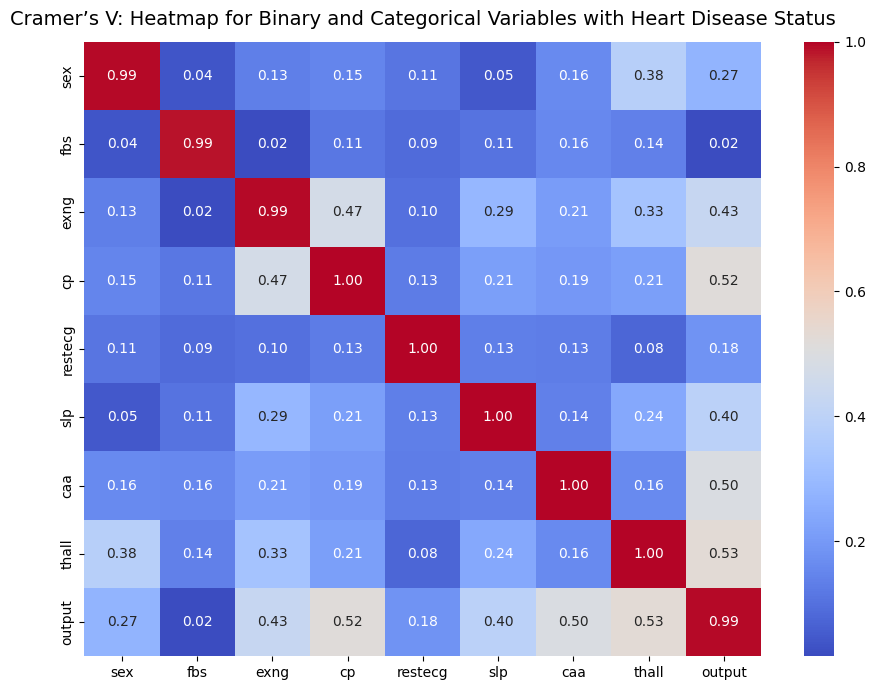

In [29]:
cat_all = binary_cols + categorical_cols + [target_col]
cramer_matrix = pd.DataFrame(index=cat_all, columns=cat_all)

for col1 in cat_all:
    for col2 in cat_all:
        cramer_matrix.loc[col1, col2] = cramers_v(heart[col1], heart[col2])

cramer_matrix = cramer_matrix.astype(float)

plt.figure(figsize=(9, 7))
sns.heatmap(cramer_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Cramer’s V: Heatmap for Binary and Categorical Variables with Heart Disease Status", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## **Combined Predictor Ranking Based on Statistical Association with Heart Disease Status**

In [30]:
# CONTINUOUS VARIABLES RANKING

target_col = 'output'
corr_cols = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

cont_results = []

for col in corr_cols:
    corr_value = full_corr.loc[col, target_col]
    cont_results.append({
        'Variable': col,
        'Variable Type': 'Continuous',
        'Statistic Used': 'Point-Biserial Correlation',
        'Score': round(corr_value, 4),
        'Absolute Score': round(abs(corr_value), 4)
    })

cont_rank = (
    pd.DataFrame(cont_results)
    .sort_values(by='Absolute Score', ascending=False)
    .reset_index(drop=True)
)


#  BINARY + MULTI-CATEGORY VARIABLES RANKING

cat_rank = assoc_df.copy()
cat_rank['Variable Type'] = cat_rank['Variable'].apply(
    lambda x: 'Binary' if x in binary_cols else 'Categorical'
)
cat_rank['Statistic Used'] = "Cramér's V"
cat_rank['Score'] = cat_rank["Cramér's V with output"]
cat_rank['Absolute Score'] = cat_rank['Score']   # already non-negative

cat_rank = cat_rank[[
    'Variable',
    'Variable Type',
    'Statistic Used',
    'Score',
    'Absolute Score'
]].sort_values(by='Absolute Score', ascending=False).reset_index(drop=True)


# COMBINE BOTH INTO ONE FINAL RANKING

combined_rank = pd.concat([cont_rank, cat_rank], axis=0, ignore_index=True)
combined_rank = combined_rank.sort_values(by='Absolute Score', ascending=False).reset_index(drop=True)
combined_rank.index = combined_rank.index + 1


# DISPLAY RESULTS

display(HTML("<h4><b>Top Continuous Predictors by Point-Biserial Correlation</b></h4>"))
display(cont_rank)

display(HTML("<h4><b>Top Binary and Categorical Predictors by Cramér’s V</b></h4>"))
display(cat_rank)

display(HTML("<h4><b>Combined Predictor Ranking Based on Statistical Association with Heart Disease Status</b></h4>"))
display(combined_rank)

,Variable,Variable Type,Statistic Used,Score,Absolute Score
0,oldpeak,Continuous,Point-Biserial Correlation,-0.4307,0.4307
1,thalachh,Continuous,Point-Biserial Correlation,0.4217,0.4217
2,age,Continuous,Point-Biserial Correlation,-0.2254,0.2254
3,trtbps,Continuous,Point-Biserial Correlation,-0.1449,0.1449
4,chol,Continuous,Point-Biserial Correlation,-0.0852,0.0852


,Variable,Variable Type,Statistic Used,Score,Absolute Score
0,thall,Categorical,Cramér's V,0.5306,0.5306
1,cp,Categorical,Cramér's V,0.5192,0.5192
2,caa,Categorical,Cramér's V,0.4954,0.4954
3,exng,Binary,Cramér's V,0.4297,0.4297
4,slp,Categorical,Cramér's V,0.3960,0.3960
5,sex,Binary,Cramér's V,0.2738,0.2738
6,restecg,Categorical,Cramér's V,0.1819,0.1819
7,fbs,Binary,Cramér's V,0.0187,0.0187


,Variable,Variable Type,Statistic Used,Score,Absolute Score
1,thall,Categorical,Cramér's V,0.5306,0.5306
2,cp,Categorical,Cramér's V,0.5192,0.5192
3,caa,Categorical,Cramér's V,0.4954,0.4954
4,oldpeak,Continuous,Point-Biserial Correlation,-0.4307,0.4307
5,exng,Binary,Cramér's V,0.4297,0.4297
6,thalachh,Continuous,Point-Biserial Correlation,0.4217,0.4217
7,slp,Categorical,Cramér's V,0.3960,0.3960
8,sex,Binary,Cramér's V,0.2738,0.2738
9,age,Continuous,Point-Biserial Correlation,-0.2254,0.2254
10,restecg,Categorical,Cramér's V,0.1819,0.1819


## **Interaction Analysis of Top Predictors with Heart Disease**

### **Interaction Between ST Depression and Maximum Heart Rate by Thalassemia Type**

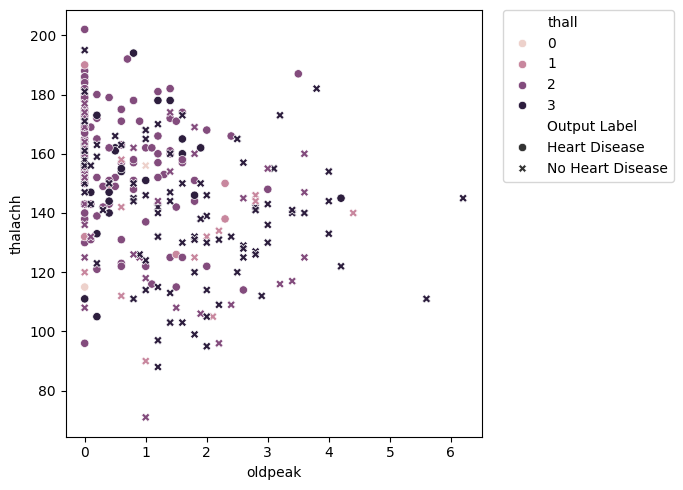

In [31]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=heart,
    x='oldpeak',
    y='thalachh',
    hue='thall',
    style='Output Label'
)

plt.legend(
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

### **Age vs Maximum Heart Rate Across Chest Pain Types**

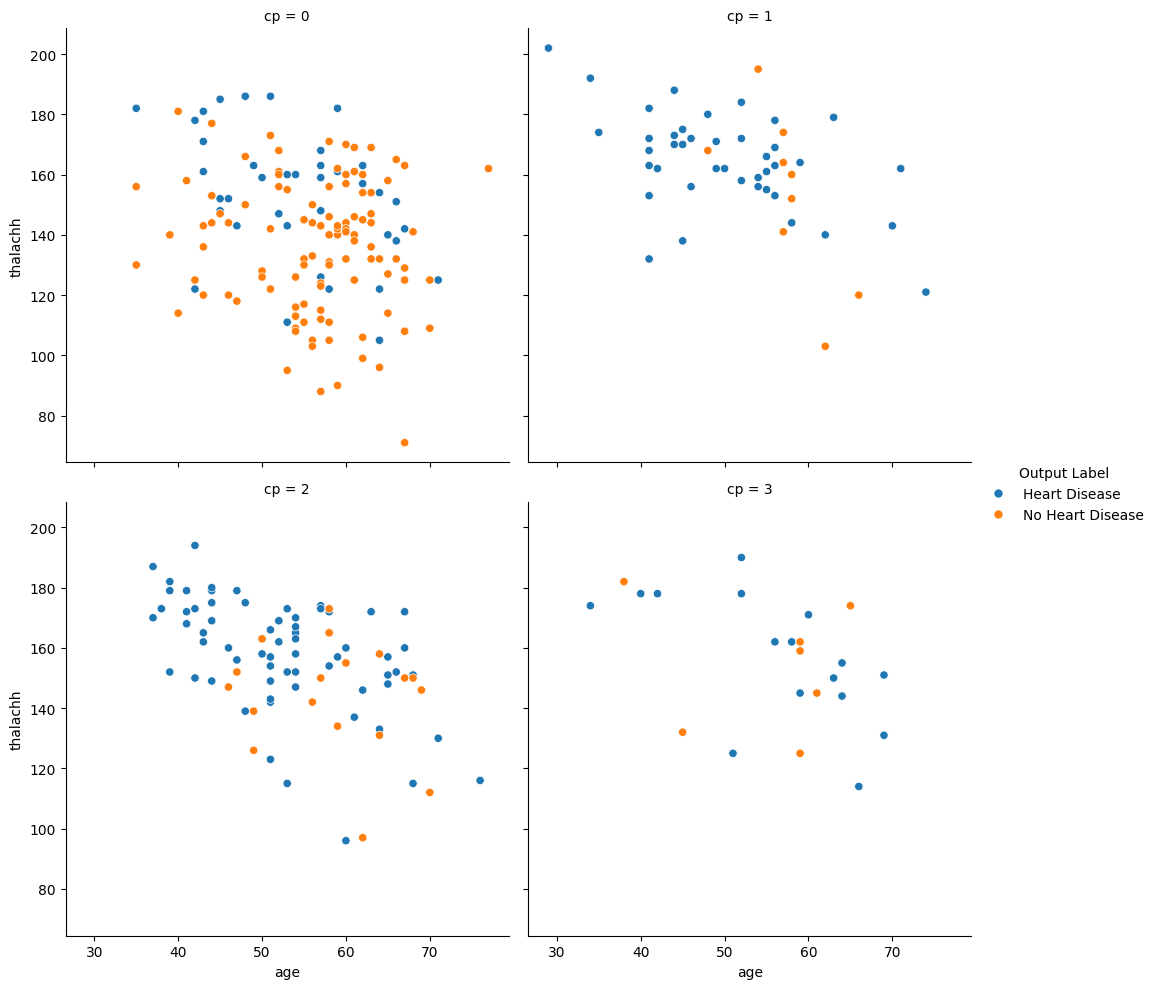

In [32]:
sns.relplot(
    data=heart,
    x='age',
    y='thalachh',
    col='cp',
    hue='Output Label',
    col_wrap=2
)

### **Age vs ST Depression (Oldpeak) by Number of Major Vessels, Heart Rate, and Heart Disease Status**

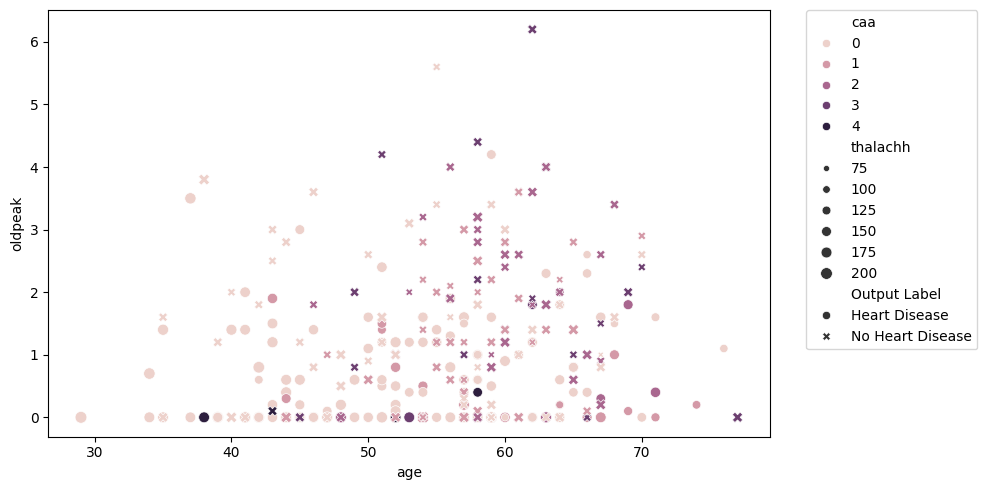

In [33]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=heart,
    x='age',
    y='oldpeak',
    hue='caa',
    size='thalachh',
    style='Output Label'
)

plt.legend(
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

### **ST Depression Across Heart Disease Groups by Exercise-Induced Angina**

<Axes: xlabel='output', ylabel='oldpeak'>

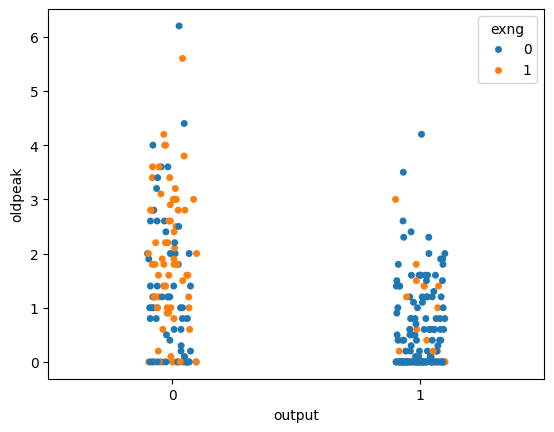

In [34]:
sns.stripplot(
    data=heart,
    x='output',
    y='oldpeak',
    hue='exng',
    jitter=True
)

### **Age vs Maximum Heart Rate by Chest Pain Type with Cholesterol as Bubble Size**

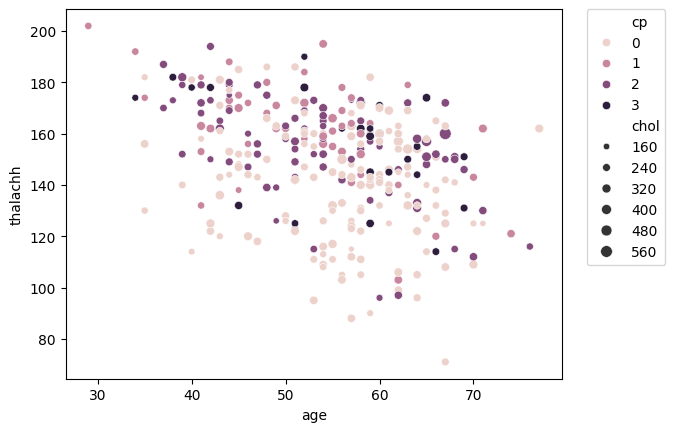

In [35]:
sns.scatterplot(
    data=heart,
    x='age',
    y='thalachh',
    size='chol',
    hue='cp'
)
plt.legend(
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    borderaxespad=0
)

### **Relationship Between ST Depression (Oldpeak) and Maximum Heart Rate Across Thalassemia Types by Heart Disease Status**

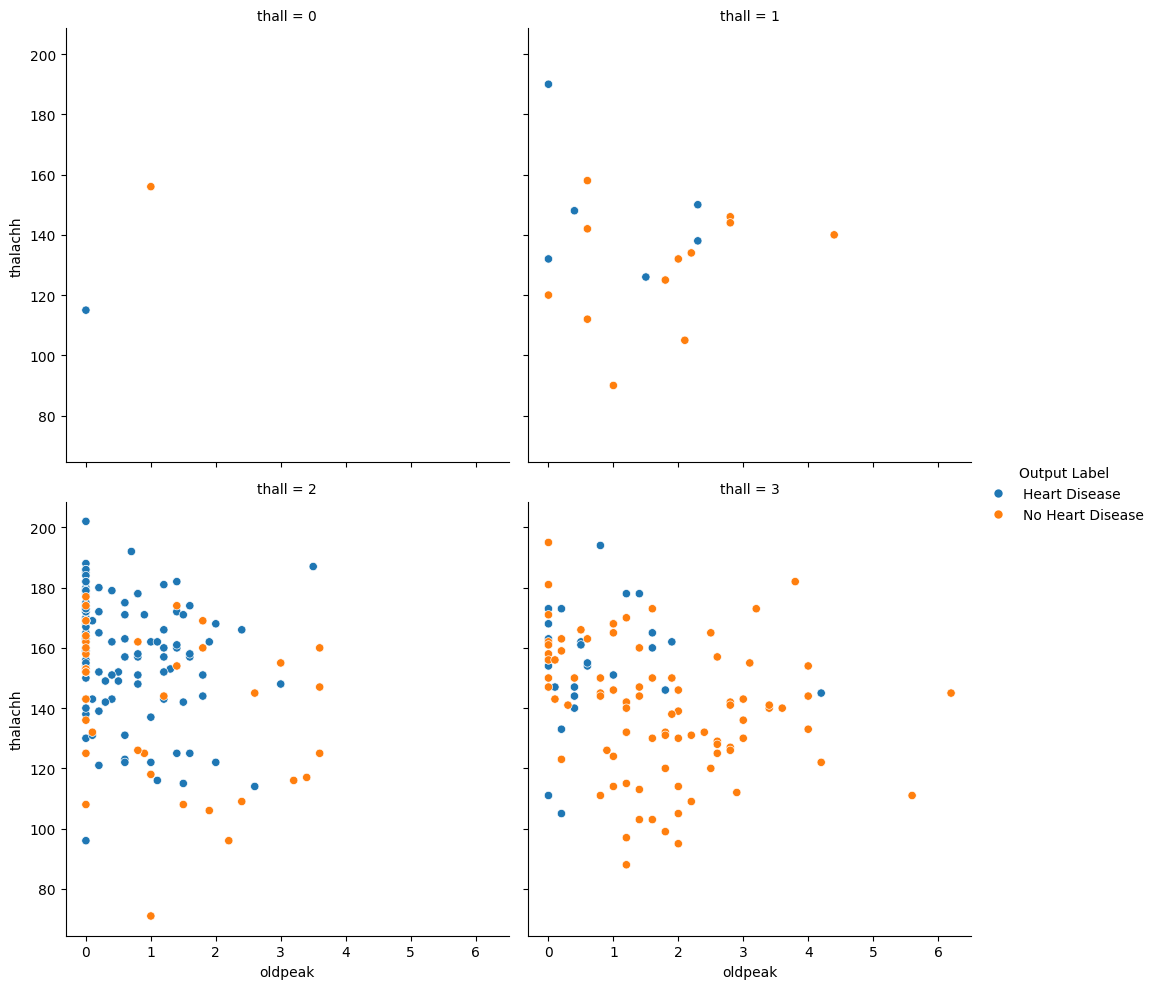

In [36]:
sns.relplot(
    data=heart,
    x='oldpeak',
    y='thalachh',
    col='thall',
    hue='Output Label',
    col_wrap=2
)

### **Relationship Between Maximum Heart Rate and ST Depression by ST Segment Slope and Heart Disease Status**

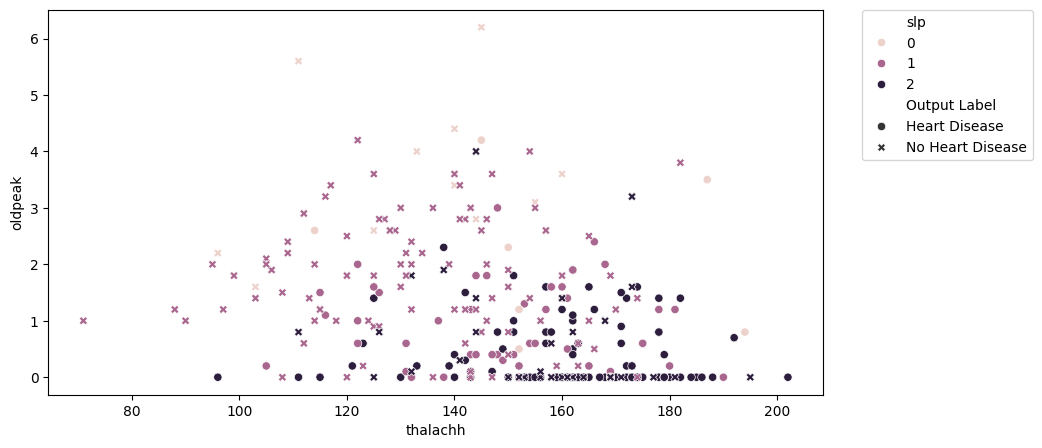

In [37]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=heart,
    x='thalachh',
    y='oldpeak',
    hue='slp',
    style='Output Label'
)
plt.legend(
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    borderaxespad=0
)

## **Modeling with Proper Feature Selection**  
### **Preparing X and y**
**X: Features/Independent Variable(s)**  
**y: Target/Dependent Variable** 

In [38]:
X = heart[['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs',
           'restecg', 'thalachh', 'exng', 'oldpeak',
           'slp', 'caa', 'thall']].copy()

y = heart['output'].copy()

### **Train-test Split of Data**  
**Train: 80% and Test: 20%**

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### **Feature Selection Based on Continuous and Categorical Association Strength**

In [40]:
selected_from_stats = []

selected_from_stats += cont_rank['Variable'].head(5).tolist()
selected_from_stats += cat_rank['Variable'].head(5).tolist()

selected_from_stats = list(dict.fromkeys(selected_from_stats))
selected_from_stats

['oldpeak',
 'thalachh',
 'age',
 'trtbps',
 'chol',
 'thall',
 'cp',
 'caa',
 'exng',
 'slp']

### **Random Forest Feature Importance**

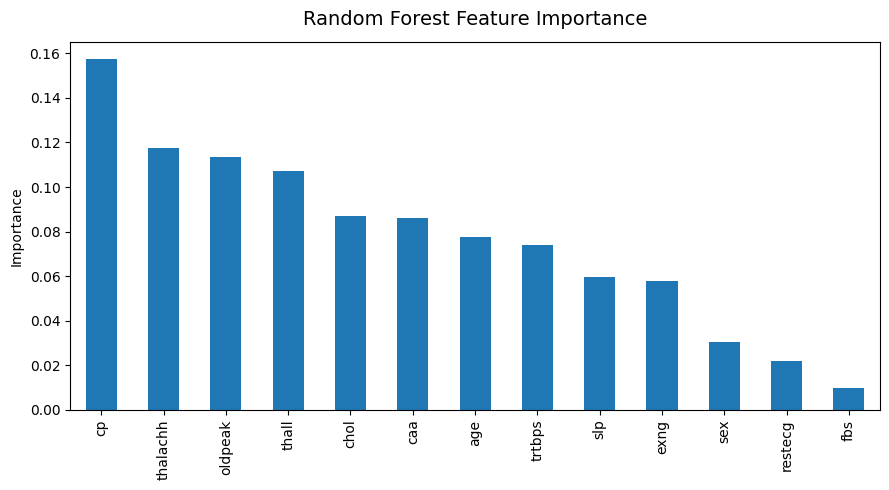

cp          0.157392
thalachh    0.117491
oldpeak     0.113399
thall       0.107062
chol        0.087131
caa         0.086078
age         0.077759
trtbps      0.074127
slp         0.059454
exng        0.057655
sex         0.030452
restecg     0.022112
fbs         0.009889
dtype: float64

['cp', 'thalachh', 'oldpeak', 'thall', 'chol', 'caa', 'age', 'trtbps']

In [41]:
rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X_train, y_train)

rf_importance = pd.Series(
    rf_temp.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
rf_importance.plot(kind='bar')
plt.title('Random Forest Feature Importance', fontsize=14, pad=12)
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

display(rf_importance)

# Select Top Features
display(HTML("<h4><b>Top Features</b></h4>"))
top_rf_features = rf_importance.head(8).index.tolist()
top_rf_features

### **Logistic Regression with L1 for Feature Selection**

In [42]:
l1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        random_state=42,
        max_iter=1000
    ))
])

l1_pipe.fit(X_train, y_train)

l1_model = l1_pipe.named_steps['clf']
l1_coefs = pd.Series(l1_model.coef_[0], index=X_train.columns)

selected_l1 = l1_coefs[l1_coefs != 0].sort_values(key=np.abs, ascending=False)

display(HTML("<h4><b>Selected Features from L1 Logistic Regression</b></h4>"))
display(selected_l1)

cp          0.916256
sex        -0.671456
oldpeak    -0.598639
thall      -0.598388
caa        -0.540529
thalachh    0.509958
exng       -0.459462
chol       -0.419145
slp         0.285265
restecg     0.208074
trtbps     -0.181566
fbs        -0.032365
dtype: float64

# **Final Feature Set**

### **Feature Aggregation**

In [43]:
final_features = list(dict.fromkeys(
    selected_from_stats +
    top_rf_features +
    selected_l1.index.tolist()
))

final_features

['oldpeak',
 'thalachh',
 'age',
 'trtbps',
 'chol',
 'thall',
 'cp',
 'caa',
 'exng',
 'slp',
 'sex',
 'restecg',
 'fbs']

### **Feature Validation and Dataset Subsetting**

In [44]:
final_features = [f for f in final_features if f in X.columns]
X_train_sel = X_train[final_features]
X_test_sel = X_test[final_features]

print(final_features)

['oldpeak', 'thalachh', 'age', 'trtbps', 'chol', 'thall', 'cp', 'caa', 'exng', 'slp', 'sex', 'restecg', 'fbs']


### **Standardization for models**

In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# **Training Models**

In [46]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        # use_label_encoder=False,
        random_state=42
    )
}

### **Evaluation function**

In [47]:
def evaluate_model(name, model, X_train_data, X_test_data, y_train, y_test):
    model.fit(X_train_data, y_train)
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

### **Model Evaluation Detail**

In [48]:
results = []

for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        res = evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test)
    else:
        res = evaluate_model(name, model, X_train_sel, X_test_sel, y_train, y_test)
    results.append(res)

# results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
results_df = (
    pd.DataFrame(results)
    .sort_values(by='ROC-AUC', ascending=False)
    .reset_index(drop=True)
)

results_df.insert(0, 'Rank', results_df.index + 1)

display(results_df)

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,Random Forest,0.803279,0.756098,0.939394,0.837838,0.898810
1,2,SVM,0.819672,0.775000,0.939394,0.849315,0.883117
2,3,Logistic Regression,0.803279,0.769231,0.909091,0.833333,0.869048
3,4,XGBoost,0.786885,0.738095,0.939394,0.826667,0.860390


### **Confusion Matrix and Classification Report for Best Model**

              precision    recall  f1-score   support

           0       0.90      0.64      0.75        28
           1       0.76      0.94      0.84        33

    accuracy                           0.80        61
   macro avg       0.83      0.79      0.79        61
weighted avg       0.82      0.80      0.80        61



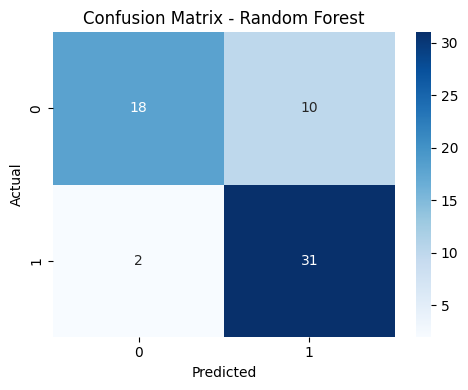

In [49]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

if best_model_name in ['Logistic Regression', 'SVM']:
    best_model.fit(X_train_scaled, y_train)
    y_pred_best = best_model.predict(X_test_scaled)
    y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    best_model.fit(X_train_sel, y_train)
    y_pred_best = best_model.predict(X_test_sel)
    y_prob_best = best_model.predict_proba(X_test_sel)[:, 1]

display(HTML(
    f"<h3 style='color: darkblue;'><b>Best Model: {best_model_name}</b></h3>"
))

print(classification_report(y_test, y_pred_best))


cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### **ROC Curve Comparison**

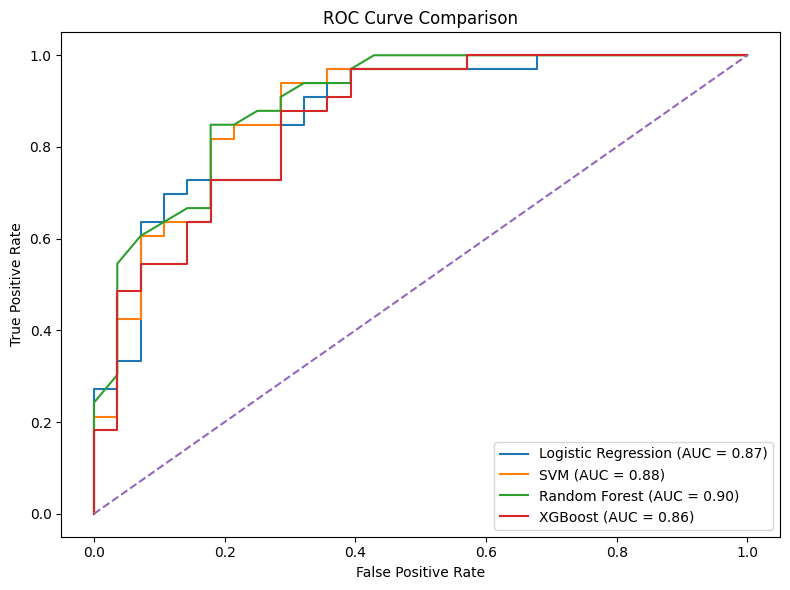

In [50]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_sel, y_train)
        y_prob = model.predict_proba(X_test_sel)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# **FINAL INSIGHT:**
**Note:**  
**Accuracy alone is misleading in medical datasets BECAUSE a model can get high accuracy but miss disease cases which is DANGEROUS**  
**So, we should use ROC-AUC / Recall / F1, not just Accuracy**  
# **Final Statement:**  
## *Multiple classification models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Among the models tested, Random Forest achieved the highest ROC-AUC score, indicating superior performance in distinguishing between patients with and without heart disease.*